# RQ4 – Drift Detection

Applies PSI drift detection across monitoring windows using the provided cybersecurity dataset.

In [1]:
import os, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

OUTPUT_DIR = "responsible_ai_outputs"
TABLE_DIR = os.path.join(OUTPUT_DIR, "tables_csv")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures_pdf")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

def find_file(possible_names):
    """Find uploaded dataset in current folder, /mnt/data, or Kaggle input folders."""
    search_roots = [".", "/mnt/data", "/kaggle/input"]
    for root in search_roots:
        if not os.path.exists(root):
            continue
        for name in possible_names:
            matches = glob.glob(os.path.join(root, "**", name), recursive=True)
            if matches:
                return matches[0]

    all_csvs = []
    for root in search_roots:
        if os.path.exists(root):
            all_csvs += glob.glob(os.path.join(root, "**", "*.csv"), recursive=True)
    for f in all_csvs:
        base = os.path.basename(f).lower()
        for name in possible_names:
            token = name.replace("(1)", "").replace(".csv","").lower()
            if token in base:
                return f
    raise FileNotFoundError(f"Could not find any of: {possible_names}")

CYBER_FILE = find_file([
    "cybersecurity_intrusion_data(1).csv",
    "cybersecurity_intrusion_data.csv"
])
cyber = pd.read_csv(CYBER_FILE)

target_col = "attack_detected"
drop_cols = ["session_id"]
cyber = cyber.drop(columns=[c for c in drop_cols if c in cyber.columns])

X = cyber.drop(columns=[target_col])
y = cyber[target_col].astype(int)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="drop"
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
pred = clf.predict(X_test)
proba = clf.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, zero_division=0),
    "recall": recall_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred, zero_division=0),
}
print("Loaded:", CYBER_FILE)
print("Dataset shape:", cyber.shape)
print("Metrics:", metrics)

def save_bar(df, x, y, title, xlabel, ylabel, filename, rotation=30):
    plt.figure(figsize=(8, 4.8))
    plt.bar(df[x].astype(str), df[y])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, format="pdf", bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)

Loaded: ./cybersecurity_intrusion_data.csv
Dataset shape: (9537, 10)
Metrics: {'accuracy': 0.8846960167714885, 'precision': 1.0, 'recall': 0.7420262664165104, 'f1': 0.8519116855142703}


Saved table: responsible_ai_outputs/tables_csv/RQ4_feature_level_drift_scores.csv
Saved table: responsible_ai_outputs/tables_csv/RQ4_drift_summary.csv


,Monitoring_Window,Average_Drift_Score,Drift_Level
0,M1,0.0000,No/Low Drift
1,M2,0.0044,No/Low Drift
2,M3,0.0046,No/Low Drift
3,M4,0.0075,No/Low Drift
4,M5,0.0043,No/Low Drift


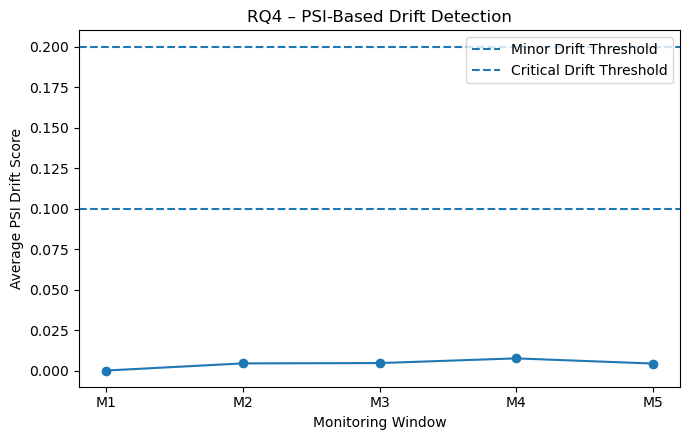

Saved figure: responsible_ai_outputs/figures_pdf/RQ4_drift_detection.pdf


In [2]:
def psi(expected, actual, bins=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()
    if expected.nunique() <= 1 or actual.nunique() <= 1:
        return 0.0

    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) <= 2:
        return 0.0

    expected_counts = np.histogram(expected, bins=breakpoints)[0] / max(len(expected), 1)
    actual_counts = np.histogram(actual, bins=breakpoints)[0] / max(len(actual), 1)
    expected_counts = np.where(expected_counts == 0, 0.0001, expected_counts)
    actual_counts = np.where(actual_counts == 0, 0.0001, actual_counts)
    return float(np.sum((actual_counts - expected_counts) * np.log(actual_counts / expected_counts)))

df_ordered = cyber.reset_index(drop=True).copy()
df_ordered["monitoring_window"] = pd.qcut(df_ordered.index, q=5, labels=["M1", "M2", "M3", "M4", "M5"])

baseline = df_ordered[df_ordered["monitoring_window"] == "M1"]
rows = []

for window, g in df_ordered.groupby("monitoring_window"):
    window_scores = []
    for col in numeric_cols:
        if col == target_col:
            continue
        score = psi(baseline[col], g[col], bins=10)
        window_scores.append(score)
        rows.append({
            "Monitoring_Window": str(window),
            "Feature": col,
            "PSI_Drift_Score": round(score, 4)
        })

drift_feature_df = pd.DataFrame(rows)
feature_csv = os.path.join(TABLE_DIR, "RQ4_feature_level_drift_scores.csv")
drift_feature_df.to_csv(feature_csv, index=False)
print("Saved table:", feature_csv)

drift_summary = drift_feature_df.groupby("Monitoring_Window", as_index=False)["PSI_Drift_Score"].mean()
drift_summary = drift_summary.rename(columns={"PSI_Drift_Score": "Average_Drift_Score"})
drift_summary["Average_Drift_Score"] = drift_summary["Average_Drift_Score"].round(4)
drift_summary["Drift_Level"] = pd.cut(
    drift_summary["Average_Drift_Score"],
    bins=[-np.inf, 0.10, 0.20, np.inf],
    labels=["No/Low Drift", "Minor Drift", "Critical Drift"]
)

summary_csv = os.path.join(TABLE_DIR, "RQ4_drift_summary.csv")
drift_summary.to_csv(summary_csv, index=False)
print("Saved table:", summary_csv)
display(drift_summary)

plt.figure(figsize=(7, 4.5))
plt.plot(drift_summary["Monitoring_Window"], drift_summary["Average_Drift_Score"], marker="o")
plt.axhline(0.10, linestyle="--", label="Minor Drift Threshold")
plt.axhline(0.20, linestyle="--", label="Critical Drift Threshold")
plt.title("RQ4 – PSI-Based Drift Detection")
plt.xlabel("Monitoring Window")
plt.ylabel("Average PSI Drift Score")
plt.legend()
plt.tight_layout()
path = os.path.join(FIG_DIR, "RQ4_drift_detection.pdf")
plt.savefig(path, format="pdf", bbox_inches="tight")
plt.show()
print("Saved figure:", path)